# 02 — Narrative Visualization

> **"Data tells you what happened. Narrative tells you why it matters."**

---

Một chart nếu chỉ hiển thị số liệu thì người xem phải tự suy luận ý nghĩa.
**Narrative Visualization** là kỹ thuật nhúng câu chuyện trực tiếp vào trong chart:
đánh dấu khi nào mọi thứ thay đổi, tại sao nó thay đổi, và giai đoạn nào là quan trọng.

### Nội dung notebook này:

1. **Turning Points** — Phát hiện và đánh dấu đỉnh / đáy tự động
2. **Event Markers** — Gắn sự kiện lịch sử lên trục thời gian
3. **Timeline Bands** — Tô màu các giai đoạn (phase / regime)
4. **Regime Shading** — Phân vùng hệ thống theo breakpoints
5. **Story Frames** — Cấu trúc hóa narrative thành các frame
6. **Narrative Caption** — Thêm takeaway text dưới chart
7. **NarrativePipeline** — Pipeline hoàn chỉnh từ data đến story

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.perception import highlight_series, fade_series
from vizint.narrative import (
    mark_turning_points,
    add_event_markers,
    add_timeline_band,
    shade_regimes,
    add_regime_labels,
    StoryFrame,
    add_narrative_caption,
)
from vizint.annotation import label_last_point, add_note, annotate_with_arrow
from vizint.pipeline import NarrativePipeline

np.random.seed(7)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data — Vietnam GDP Growth (simulated)

Dữ liệu giả lập tăng trưởng GDP theo quý trong 15 năm (2009–2024).
Gồm 4 giai đoạn rõ ràng:
- **Recovery** (2009–2012): phục hồi sau khủng hoảng tài chính
- **Stable Growth** (2012–2019): tăng trưởng ổn định
- **Crisis** (2020–2021): COVID-19
- **Rebound** (2022–2024): phục hồi mạnh

In [2]:
# Quarterly data: 2009 Q1 → 2024 Q4  (64 quarters)
n_quarters = 64
quarters   = np.arange(n_quarters)

# Simulate GDP growth rate (%)
def make_gdp_series(seed=7):
    rng = np.random.default_rng(seed)
    y = np.zeros(n_quarters)
    # Phase 1: Recovery 2009-2012 (Q0-Q15)
    y[:16]  = 5.5 + np.linspace(0, 1.5, 16) + rng.normal(0, 0.4, 16)
    # Phase 2: Stable Growth 2012-2019 (Q16-Q43)
    y[16:44] = 6.8 + rng.normal(0, 0.5, 28)
    # Phase 3: COVID Crisis 2020-2021 (Q44-Q51)
    y[44:52] = np.array([3.8, 0.4, -6.1, -4.5, 4.5, 5.6, 5.2, 5.8])
    # Phase 4: Rebound 2022-2024 (Q52-Q63)
    y[52:]   = 7.2 + np.linspace(0, -0.8, 12) + rng.normal(0, 0.4, 12)
    return y

y_gdp = make_gdp_series()

# Quarter labels for x-axis ticks
year_ticks  = [i for i in range(n_quarters) if i % 4 == 0]
year_labels = [str(2009 + i // 4) for i in year_ticks]

# Key events
EVENTS = [
    (12,  'Basel III'),
    (28,  'TPP signed'),
    (44,  'COVID-19'),
    (52,  'Recovery plan'),
]

# Regime breakpoints (quarter index)
BREAKPOINTS = [16, 44, 52]
REGIME_LABELS = ['Recovery', 'Stable Growth', 'COVID Crisis', 'Rebound']

print(f'Quarters: {n_quarters}  |  GDP range: [{y_gdp.min():.1f}%, {y_gdp.max():.1f}%]')

Quarters: 64  |  GDP range: [-6.1%, 7.7%]


---
## 1. Turning Points

**Turning point** = điểm mà xu hướng đảo chiều — đỉnh cục bộ hoặc đáy cục bộ.

`mark_turning_points` dùng `scipy.signal.argrelextrema` để phát hiện tự động.
Tham số `order` kiểm soát độ nhạy:
- `order` nhỏ → nhạy hơn, bắt nhiều điểm hơn (có thể nhiễu)
- `order` lớn → chỉ bắt các đảo chiều lớn (ít nhiễu hơn)

Kết hợp `show_labels=True` để hiển thị giá trị ngay tại điểm.

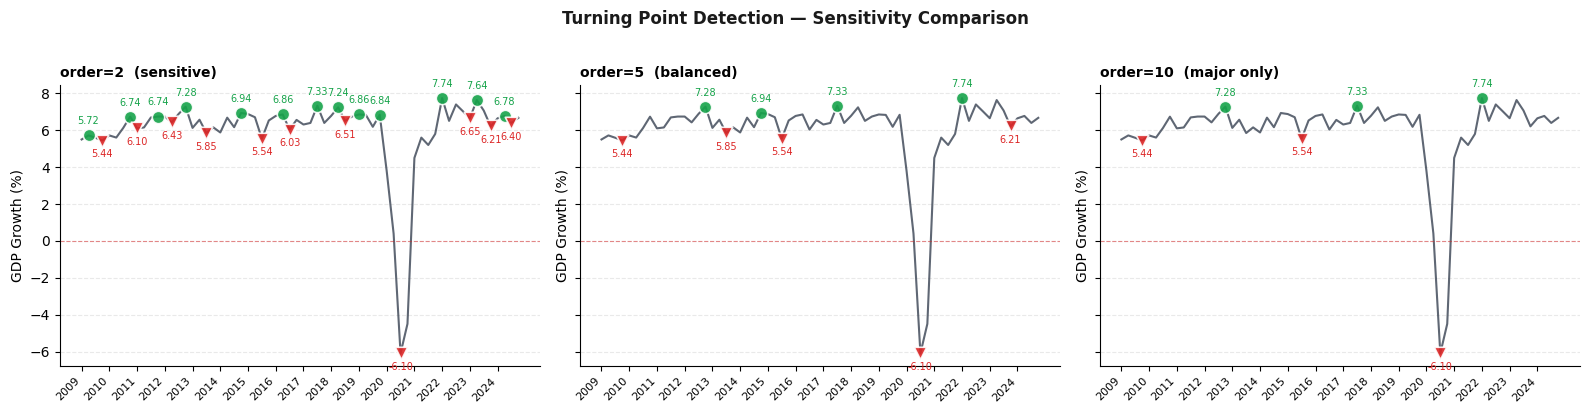

In [3]:
# So sánh order khác nhau
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white', sharey=True)

for ax, order, title in zip(
    axes,
    [2, 5, 10],
    ['order=2  (sensitive)', 'order=5  (balanced)', 'order=10  (major only)']
):
    ax.plot(quarters, y_gdp, color='#374151', linewidth=1.5, alpha=0.8)
    ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle='--', alpha=0.5)
    mark_turning_points(ax, quarters, y_gdp, order=order,
                        max_color='#16A34A', min_color='#DC2626',
                        show_labels=True, label_fontsize=7)
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('GDP Growth (%)')
    despine(ax); set_grid(ax)

fig.suptitle('Turning Point Detection — Sensitivity Comparison',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Event Markers

**Event markers** = đường dọc đánh dấu thời điểm xảy ra sự kiện quan trọng.

`add_event_markers` nhận danh sách vị trí x và nhãn tương ứng.
Nhãn được rotate 90° và đặt gần đỉnh axes để không che data.

**Khi nào dùng:** khi bạn muốn người xem hiểu *tại sao* series thay đổi tại một thời điểm cụ thể.

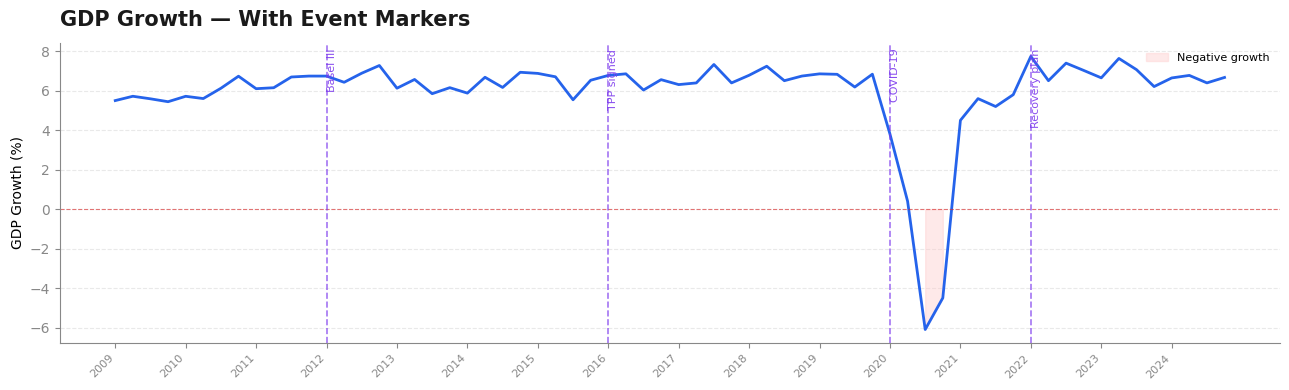

In [4]:
chart = (
    ChartBuilder(figsize=(13, 4))
    .set_title('GDP Growth — With Event Markers')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle='--', alpha=0.6)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.4, label='Negative growth')

# Event markers
event_x, event_labels = zip(*EVENTS)
add_event_markers(
    ax,
    x_positions=event_x,
    labels=list(event_labels),
    color='#7C3AED',
    linewidth=1.2,
    linestyle='--',
    label_fontsize=8,
    label_rotation=90,
)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Timeline Bands

**Timeline band** = vùng tô màu đại diện cho một giai đoạn kéo dài (policy period, crisis window, campaign).

`add_timeline_band` tô màu từ `xmin` đến `xmax` và có thể thêm label ở giữa band.

So sánh với event marker:
- **Event marker** → thời điểm cụ thể (1 dòng dọc)
- **Timeline band** → giai đoạn kéo dài (vùng màu)

Hai loại có thể dùng cùng nhau.

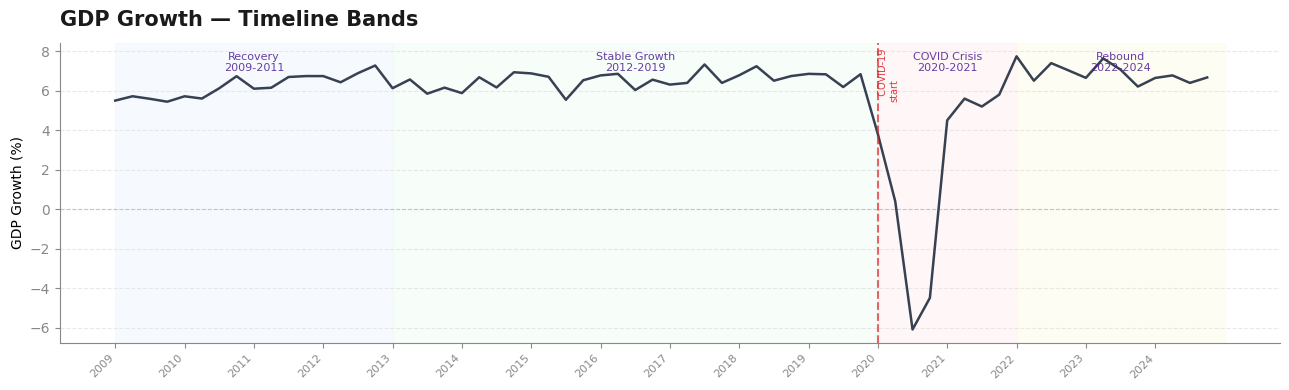

In [5]:
chart = (
    ChartBuilder(figsize=(13, 4))
    .set_title('GDP Growth — Timeline Bands')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#374151', linewidth=1.8, zorder=3)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)

# Bands cho từng giai đoạn
band_defs = [
    (0,  16, 'Recovery\n2009-2011',  '#EFF6FF', 0.5),
    (16, 44, 'Stable Growth\n2012-2019', '#F0FDF4', 0.5),
    (44, 52, 'COVID Crisis\n2020-2021',  '#FFF1F2', 0.6),
    (52, 64, 'Rebound\n2022-2024',       '#FEFCE8', 0.5),
]

for xmin, xmax, label, color, alpha in band_defs:
    add_timeline_band(ax, xmin, xmax, label=label,
                      color=color, alpha=alpha,
                      label_y=0.97, label_fontsize=8)

# Event markers chồng lên bands
add_event_markers(ax, [44], ['COVID-19\nstart'], color='#DC2626',
                  linewidth=1.5, label_fontsize=7)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

---
## 4. Regime Shading

**Regime** = trạng thái hệ thống trong một giai đoạn. Khác với timeline band ở chỗ:
- **Timeline band** — dùng màu và label tự chọn, thường có ngữ nghĩa cụ thể
- **Regime shading** — tô xen kẽ (alternating) nhiều regime, nhấn mạnh ranh giới hơn là màu sắc

`shade_regimes` tự động tô xen kẽ từ `breakpoints`.
`add_regime_labels` thêm tên vào giữa mỗi regime band.

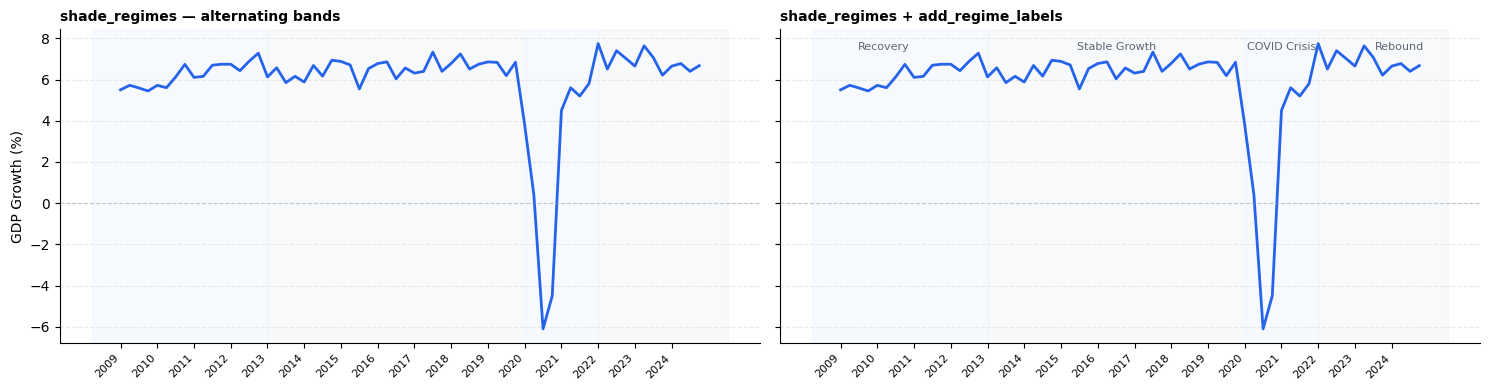

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), facecolor='white', sharey=True)

# Panel 1: regime shading chỉ
ax = axes[0]
ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
shade_regimes(ax, breakpoints=BREAKPOINTS,
              colors=['#EFF6FF', '#F1F5F9'], alpha=0.5)
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('shade_regimes — alternating bands', loc='left', fontsize=10, fontweight='bold')
ax.set_ylabel('GDP Growth (%)')
despine(ax); set_grid(ax)

# Panel 2: regime shading + labels
ax = axes[1]
ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
shade_regimes(ax, breakpoints=BREAKPOINTS,
              colors=['#EFF6FF', '#F1F5F9'], alpha=0.5)
add_regime_labels(ax, breakpoints=BREAKPOINTS, labels=REGIME_LABELS,
                  y_position=0.96, fontsize=8, color='#374151')
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('shade_regimes + add_regime_labels', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 5. Story Frames

**`StoryFrame`** là dataclass cấu trúc hóa một narrative:

```python
StoryFrame(
    title   = 'COVID Shock',        # Headline ngắn
    body    = 'GDP giảm -6.1%...',  # Giải thích 1-3 câu
    xmin    = 44,                   # Bắt đầu giai đoạn
    xmax    = 52,                   # Kết thúc giai đoạn
    highlights = ['GDP'],           # Series liên quan
)
```

Dùng `build_story_sequence` để in toàn bộ narrative dưới dạng text summary.
Dùng frame để tự động highlight vùng tương ứng trên chart.

In [7]:
from vizint.narrative.story import build_story_sequence

frames = [
    StoryFrame(
        title='Post-GFC Recovery',
        body='GDP growth rebounded steadily from 5.5% to 7%+ as trade recovered and domestic demand strengthened.',
        xmin=0, xmax=16,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='Stable Growth Era',
        body='Seven years of consistent 6-7% growth driven by FDI inflows, export expansion, and structural reforms.',
        xmin=16, xmax=44,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='COVID-19 Shock',
        body='Q3 2020 saw GDP contract to -6.1%, the steepest decline on record, before rapid containment measures took hold.',
        xmin=44, xmax=52,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='Strong Rebound',
        body='Economic reopening and pent-up demand drove growth back above 7%, with recovery outpacing regional peers.',
        xmin=52, xmax=64,
        highlights=['GDP'],
    ),
]

# Print narrative sequence
for line in build_story_sequence(frames):
    print(line)
    print()

1. Post-GFC Recovery: GDP growth rebounded steadily from 5.5% to 7%+ as trade recovered and domestic demand strengthened.

2. Stable Growth Era: Seven years of consistent 6-7% growth driven by FDI inflows, export expansion, and structural reforms.

3. COVID-19 Shock: Q3 2020 saw GDP contract to -6.1%, the steepest decline on record, before rapid containment measures took hold.

4. Strong Rebound: Economic reopening and pent-up demand drove growth back above 7%, with recovery outpacing regional peers.



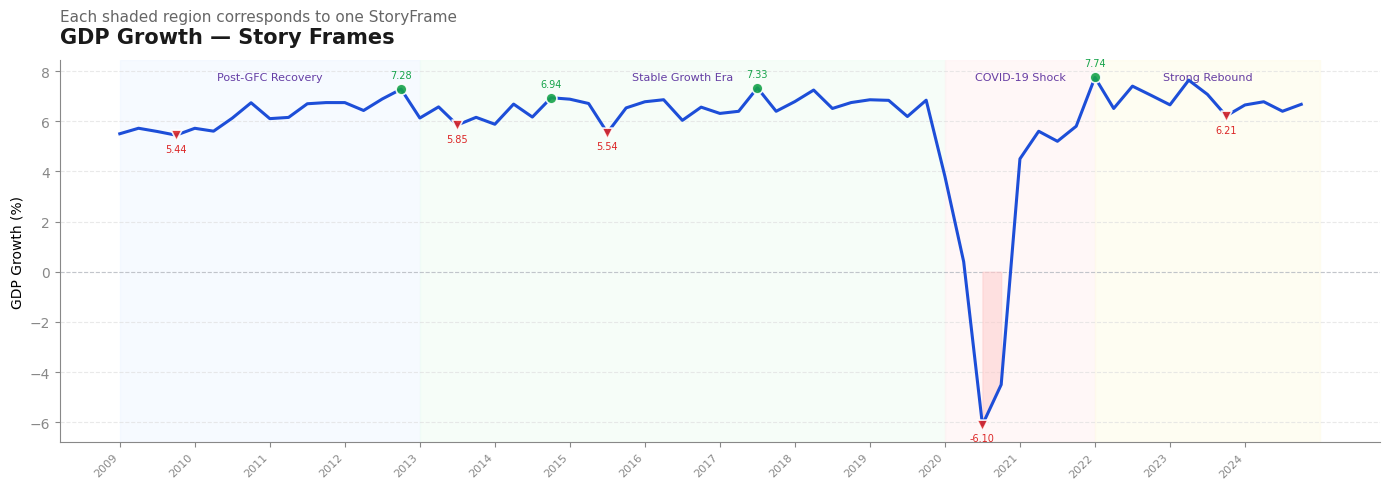

In [8]:
# Render story frames lên chart — mỗi frame = một vùng màu khác nhau
frame_colors = ['#EFF6FF', '#F0FDF4', '#FFF1F2', '#FEFCE8']
frame_border = ['#93C5FD', '#86EFAC', '#FCA5A5', '#FDE68A']

chart = (
    ChartBuilder(figsize=(14, 5))
    .set_title('GDP Growth — Story Frames')
    .set_subtitle('Each shaded region corresponds to one StoryFrame')
    .build()
)
ax = chart.ax

# Render each frame as a timeline band
for frame, fc, bc in zip(frames, frame_colors, frame_border):
    add_timeline_band(ax, frame.xmin, frame.xmax,
                      label=frame.title,
                      color=fc, alpha=0.55,
                      label_y=0.97, label_fontsize=8)

# Plot data on top
ax.plot(quarters, y_gdp, color='#1D4ED8', linewidth=2.2, zorder=5)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.5, zorder=4)

# Turning points
mark_turning_points(ax, quarters, y_gdp, order=6,
                    max_color='#16A34A', min_color='#DC2626',
                    show_labels=True, label_fontsize=7, size=60)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

---
## 6. Narrative Caption

**Caption** là dòng takeaway đặt dưới chart — câu quan trọng nhất mà người xem cần nhớ.

Nguyên tắc viết caption tốt:
- Nói **insight**, không mô tả lại chart
- Ngắn gọn: 1–2 câu
- Dùng số cụ thể nếu có

❌ **Mô tả:** *"GDP growth fluctuated between -6.1% and 7.8% during the period."*

✓ **Insight:** *"Despite the COVID shock, Vietnam's growth trajectory returned to pre-pandemic levels within 6 quarters — faster than most peers."*

C:\Users\Duy\AppData\Local\Temp\ipykernel_10044\1135316065.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout(pad=2.5)
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


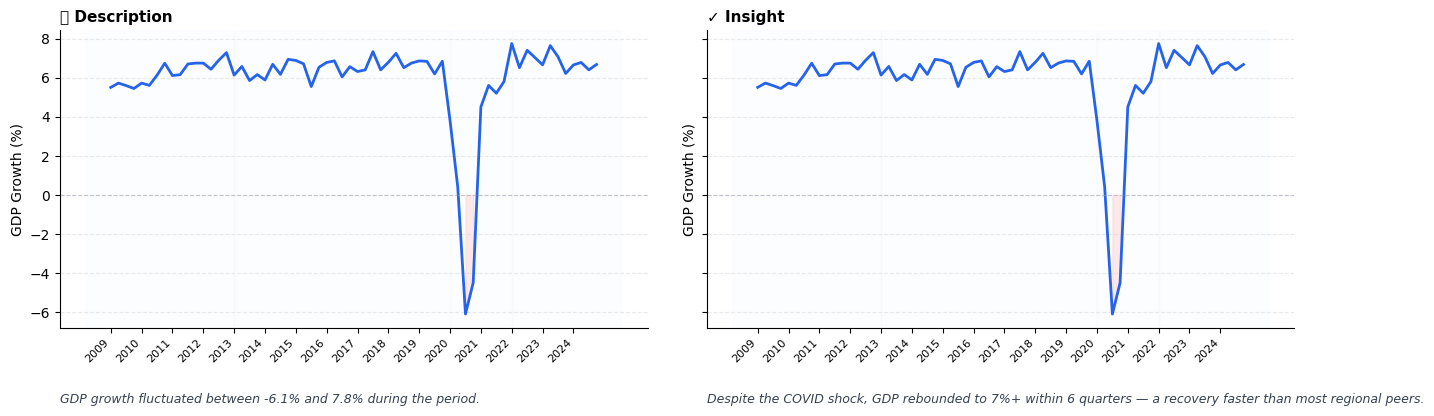

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white', sharey=True)

caption_bad  = "GDP growth fluctuated between -6.1% and 7.8% during the period."
caption_good = "Despite the COVID shock, GDP rebounded to 7%+ within 6 quarters — a recovery faster than most regional peers."

for ax, caption, tag in zip(axes, [caption_bad, caption_good], ['❌ Description', '✓ Insight']):
    ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
    ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.fill_between(quarters, y_gdp, 0,
                    where=(y_gdp < 0), color='#FECACA', alpha=0.4)
    shade_regimes(ax, BREAKPOINTS, alpha=0.15)

    add_narrative_caption(ax, caption,
                          y=-0.22, fontsize=9,
                          color='#374151', style='italic')

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(tag, loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel('GDP Growth (%)')
    despine(ax); set_grid(ax)

plt.tight_layout(pad=2.5)
plt.show()

---
## 7. Arrow Annotations

Khi một điểm dữ liệu cần được giải thích bằng text, dùng arrow annotation để kết nối text với điểm đó.

`annotate_with_arrow` — text thuần túy + mũi tên (dùng cho insight ngắn gọn).

Tham số `connectionstyle='arc3,rad=X'` kiểm soát độ cong của mũi tên:
- `rad=0` → đường thẳng
- `rad=0.2` → cong nhẹ
- `rad=0.4` → cong rõ hơn (tránh đè lên data)

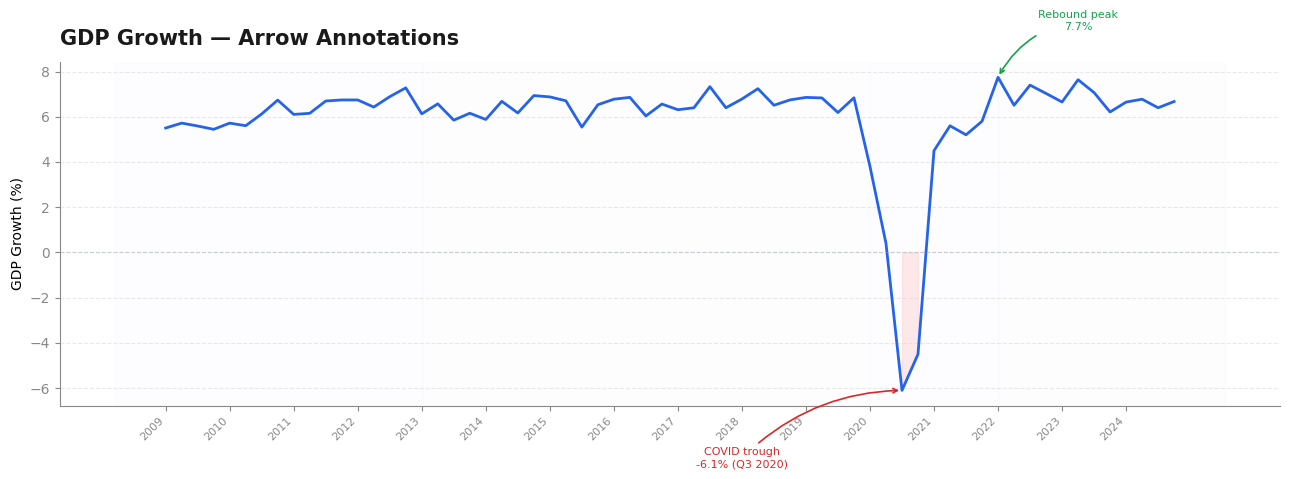

In [10]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('GDP Growth — Arrow Annotations')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.4)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.4)

shade_regimes(ax, BREAKPOINTS, alpha=0.12)

# Tìm đáy COVID
covid_trough_idx = 44 + np.argmin(y_gdp[44:52])

# Annotate đáy COVID
annotate_with_arrow(
    ax,
    text=f'COVID trough\n{y_gdp[covid_trough_idx]:.1f}% (Q3 2020)',
    xy=(covid_trough_idx, y_gdp[covid_trough_idx]),
    xytext=(covid_trough_idx - 10, y_gdp[covid_trough_idx] - 3),
    fontsize=8,
    color='#DC2626',
    arrowcolor='#DC2626',
    connectionstyle='arc3,rad=-0.2',
    ha='center',
)

# Annotate peak rebound
rebound_peak_idx = 52 + np.argmax(y_gdp[52:])
annotate_with_arrow(
    ax,
    text=f'Rebound peak\n{y_gdp[rebound_peak_idx]:.1f}%',
    xy=(rebound_peak_idx, y_gdp[rebound_peak_idx]),
    xytext=(rebound_peak_idx + 5, y_gdp[rebound_peak_idx] + 2.5),
    fontsize=8,
    color='#16A34A',
    arrowcolor='#16A34A',
    connectionstyle='arc3,rad=0.25',
    ha='center',
)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

---
## 8. NarrativePipeline — Full Storytelling in One Call

`NarrativePipeline` là high-level class kết hợp tất cả layer của narrative:

```
Regime shading
    → Background series (faded)
        → Signal series (highlighted)
            → Mean reference
                → Turning points
                    → Event markers
                        → Caption
```

Toàn bộ pipeline trên được thực hiện bằng fluent API, không cần viết từng bước thủ công.

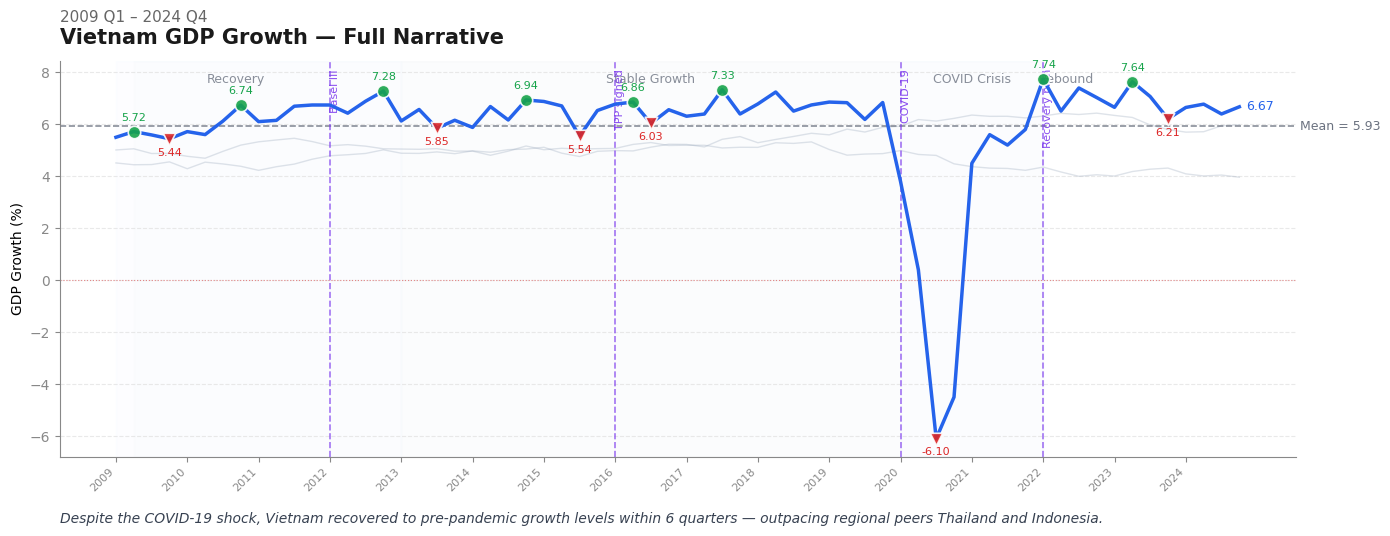

In [11]:
# Background: 2 nước khác trong khu vực (simulated)
rng = np.random.default_rng(99)
bg_series = {
    'Thailand': 4.5 + np.cumsum(rng.normal(0, 0.15, n_quarters)),
    'Indonesia': 5.0 + np.cumsum(rng.normal(0, 0.13, n_quarters)),
}

chart = (
    NarrativePipeline(
        x=quarters,
        y=y_gdp,
        title='Vietnam GDP Growth — Full Narrative',
        subtitle='2009 Q1 – 2024 Q4',
        figsize=(14, 5.5),
        signal_color='#2563EB',
    )
    .add_regimes(
        breakpoints=BREAKPOINTS,
        labels=REGIME_LABELS,
    )
    .add_background(bg_series)
    .add_events(EVENTS)
    .add_turning_points()
    .add_mean_reference()
    .add_caption(
        'Despite the COVID-19 shock, Vietnam recovered to pre-pandemic growth levels '
        'within 6 quarters — outpacing regional peers Thailand and Indonesia.'
    )
    .run()
)

ax = chart.ax
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')
ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 9. Comparing Narrative Depth

Cùng một dataset — 3 mức độ narrative khác nhau:

- **Level 0** — Raw chart (không có narrative)
- **Level 1** — Events + turning points
- **Level 2** — Regimes + events + turning points + caption

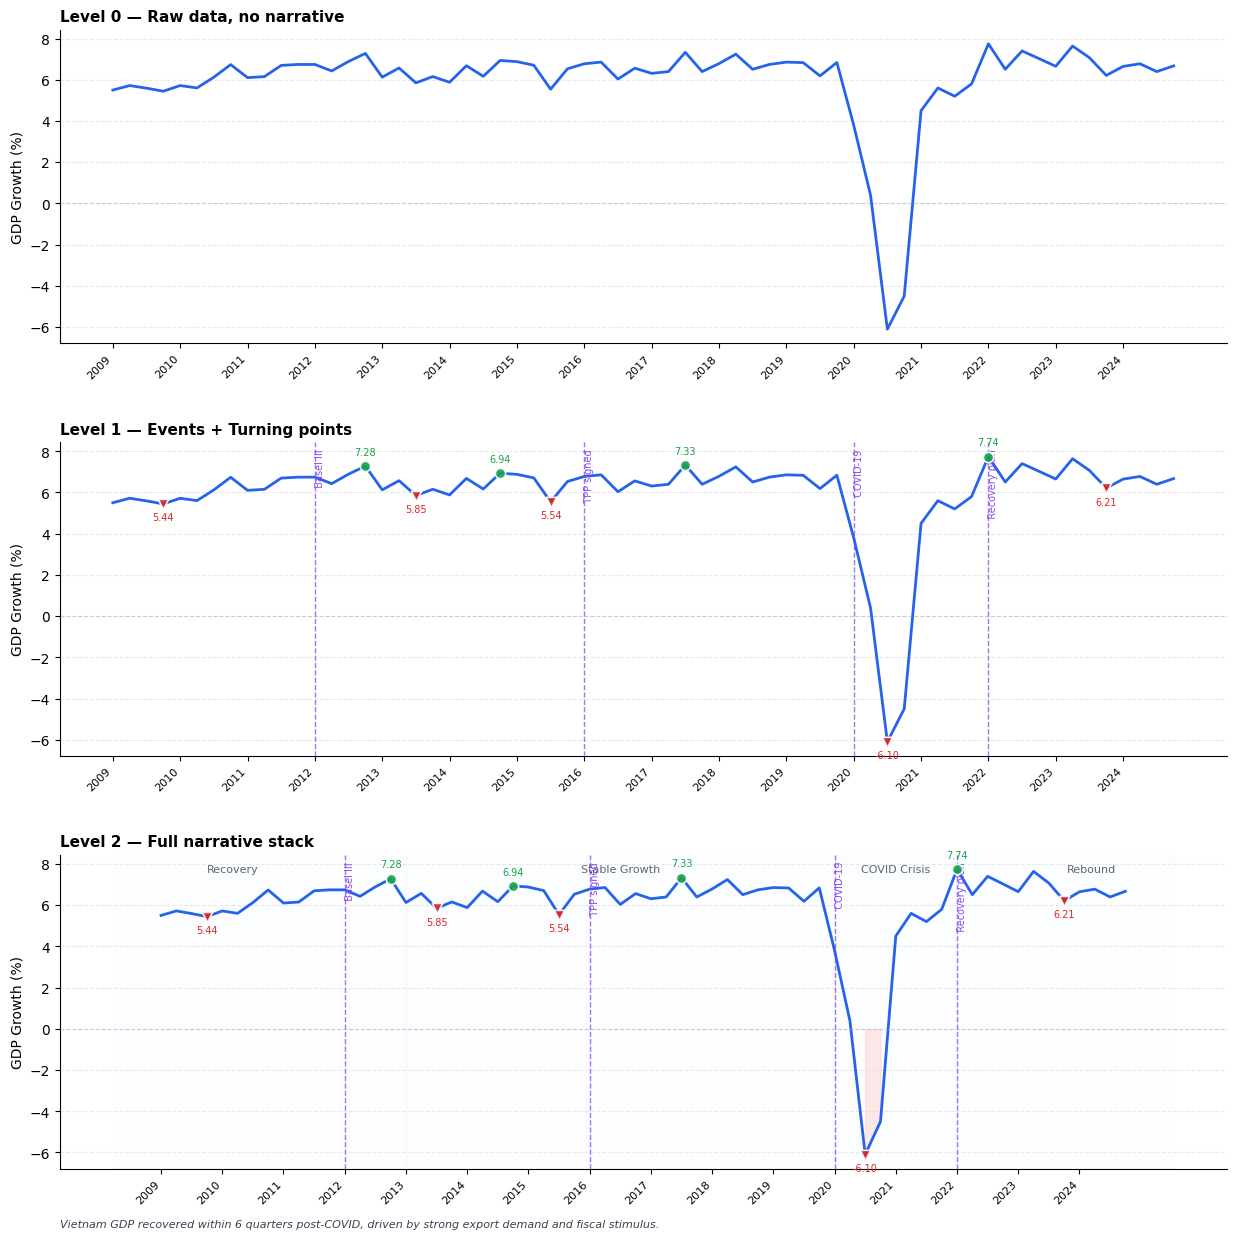

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13), facecolor='white')
titles = [
    'Level 0 — Raw data, no narrative',
    'Level 1 — Events + Turning points',
    'Level 2 — Full narrative stack',
]

for level, (ax, title) in enumerate(zip(axes, titles)):
    # Base: always plot the series
    ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
    ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.4)

    if level >= 1:
        # Add events and turning points
        add_event_markers(ax, [x for x, _ in EVENTS],
                          labels=[l for _, l in EVENTS],
                          color='#7C3AED', linewidth=1.0, label_fontsize=7)
        mark_turning_points(ax, quarters, y_gdp, order=6,
                            max_color='#16A34A', min_color='#DC2626',
                            show_labels=True, label_fontsize=7, size=55)

    if level >= 2:
        # Add regimes + labels + caption
        shade_regimes(ax, BREAKPOINTS, alpha=0.15)
        add_regime_labels(ax, BREAKPOINTS, REGIME_LABELS, fontsize=8, color='#374151')
        ax.fill_between(quarters, y_gdp, 0,
                        where=(y_gdp < 0), color='#FECACA', alpha=0.4)
        add_narrative_caption(
            ax,
            'Vietnam GDP recovered within 6 quarters post-COVID, '
            'driven by strong export demand and fiscal stimulus.',
            y=-0.16, fontsize=8
        )

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('GDP Growth (%)')
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')
    despine(ax); set_grid(ax)

plt.tight_layout(pad=3.0)
plt.show()

---
## Summary

| Technique | Function | Khi nào dùng |
|-----------|----------|-------------|
| Turning points | `mark_turning_points` | Tự động đánh dấu đỉnh/đáy |
| Event marker | `add_event_markers` | Gắn sự kiện vào thời điểm cụ thể |
| Timeline band | `add_timeline_band` | Giai đoạn kéo dài có tên |
| Regime shading | `shade_regimes` | Phân vùng hệ thống xen kẽ |
| Regime labels | `add_regime_labels` | Tên cho từng regime |
| Story frames | `StoryFrame` | Cấu trúc hóa narrative thành objects |
| Narrative caption | `add_narrative_caption` | Takeaway text dưới chart |
| Arrow annotation | `annotate_with_arrow` | Giải thích điểm dữ liệu cụ thể |
| Full pipeline | `NarrativePipeline` | One-call storytelling chart |

---

### Key Takeaway

> Narrative không phải là thêm chữ vào chart.
> Narrative là **cấu trúc hóa thông tin** để người xem hiểu *khi nào*, *tại sao*, và *ý nghĩa là gì* — không cần phải đọc thêm bất kỳ tài liệu nào khác.

**Next →** `03_context_and_comparison.ipynb` — Số liệu chỉ có ý nghĩa khi có ngưỡng tham chiếu: benchmark, target, và so sánh trực tiếp.